# EDA: Prediksi Ketepatan Lulus Mahasiswa
---
**Tujuan**: Memahami dataset sebelum preprocessing — identifikasi missing values, distribusi, korelasi, dan sinyal fitur terhadap target.

**Data**: `dataset.csv` (608 rows x 27 kolom)  
**Target**: `1` = Tepat Waktu, `0` = Tidak Tepat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline

In [2]:
df = pd.read_csv('dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (608, 27)


,student_id,angkatan,program,jenis_kelamin,id_agama,ips_sem1,ips_sem2,ips_sem3,ips_sem4,ipk_sem4,sks_sem1,sks_sem2,sks_sem3,sks_sem4,total_sks_lulus_sem4,failed_courses,failed_in_sem1,repeated_courses,avg_attendance,ips_trend,avg_ips,ips_std,ips_max,ips_min,sks_completion_ratio,semester_count,target
0,207421001,2020,IH,P,2,2.9000,3.4300,3.1700,3.6300,3.2800,20.0000,21.0000,18.0000,19.0000,78,1,1,0,83.6700,0.7300,3.2825,0.3170,3.6300,2.9000,0.9750,8,1
1,207421003,2020,IH,P,1,3.4500,3.4300,3.3300,3.2600,3.3700,20.0000,21.0000,18.0000,19.0000,78,1,0,0,81.6700,-0.1900,3.3675,0.0888,3.4500,3.2600,0.9750,8,1
2,207421004,2020,IH,L,1,3.1000,3.3300,3.3300,3.3700,3.2800,20.0000,21.0000,18.0000,19.0000,78,0,0,0,83.0800,0.2700,3.2825,0.1231,3.3700,3.1000,0.9750,8,1
3,207421005,2020,IH,L,1,3.1000,3.2400,3.6700,0.0000,2.5100,20.0000,21.0000,18.0000,19.0000,78,8,0,0,78.9700,-3.1000,2.5025,1.6859,3.6700,0.0000,0.9750,4,0
4,207421006,2020,IH,L,1,3.2000,3.4300,3.3300,3.6300,3.4000,20.0000,21.0000,18.0000,19.0000,78,0,0,0,82.0900,0.4300,3.3975,0.1814,3.6300,3.2000,0.9750,4,0


## 1. Structure & Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            608 non-null    str    
 1   angkatan              608 non-null    int64  
 2   program               608 non-null    str    
 3   jenis_kelamin         608 non-null    str    
 4   id_agama              608 non-null    int64  
 5   ips_sem1              441 non-null    float64
 6   ips_sem2              489 non-null    float64
 7   ips_sem3              590 non-null    float64
 8   ips_sem4              417 non-null    float64
 9   ipk_sem4              608 non-null    float64
 10  sks_sem1              441 non-null    float64
 11  sks_sem2              489 non-null    float64
 12  sks_sem3              590 non-null    float64
 13  sks_sem4              417 non-null    float64
 14  total_sks_lulus_sem4  608 non-null    int64  
 15  failed_courses        608 non-null

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,608,608,207421001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
angkatan,608.0000,NaN,NaN,NaN,2019.1760,2.9309,2015.0000,2016.0000,2020.0000,2022.0000,2023.0000
program,608,2,IH,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jenis_kelamin,608,2,L,407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_agama,608.0000,NaN,NaN,NaN,1.1382,0.3985,1.0000,1.0000,1.0000,1.0000,4.0000
ips_sem1,441.0000,NaN,NaN,NaN,1.9623,1.5783,0.0000,0.0000,3.0000,3.2500,4.0000
ips_sem2,489.0000,NaN,NaN,NaN,3.2217,0.4670,0.0000,3.1300,3.2500,3.3800,4.0000
ips_sem3,590.0000,NaN,NaN,NaN,3.4794,0.6180,0.0000,3.1500,3.6700,3.8775,4.0000
ips_sem4,417.0000,NaN,NaN,NaN,2.8929,1.0037,0.0000,3.0000,3.1100,3.4300,4.0000
ipk_sem4,608.0000,NaN,NaN,NaN,3.1964,0.4379,0.7500,3.0275,3.2300,3.3600,4.0000


In [5]:
# Drop student_id (not a feature)
df_eda = df.drop(columns=['student_id'])

# Separate feature groups
cat_cols = ['program', 'jenis_kelamin', 'id_agama']
ips_cols = ['ips_sem1', 'ips_sem2', 'ips_sem3', 'ips_sem4']
sks_cols = ['sks_sem1', 'sks_sem2', 'sks_sem3', 'sks_sem4']
grade_cols = ['failed_courses', 'failed_in_sem1', 'repeated_courses']
derived_cols = ['ips_trend', 'avg_ips', 'ips_std', 'ips_max', 'ips_min', 
                'sks_completion_ratio', 'semester_count', 'avg_attendance']
meta_cols = ['angkatan', 'ipk_sem4', 'total_sks_lulus_sem4']
target_col = 'target'

## 2. Missing Values Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, '%': missing_pct})
missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

,Count,%
avg_attendance,321,52.8000
ips_sem4,191,31.4000
sks_sem4,191,31.4000
ips_sem1,167,27.5000
sks_sem1,167,27.5000
ips_sem2,119,19.6000
sks_sem2,119,19.6000
ips_max,118,19.4000
ips_trend,118,19.4000
avg_ips,118,19.4000


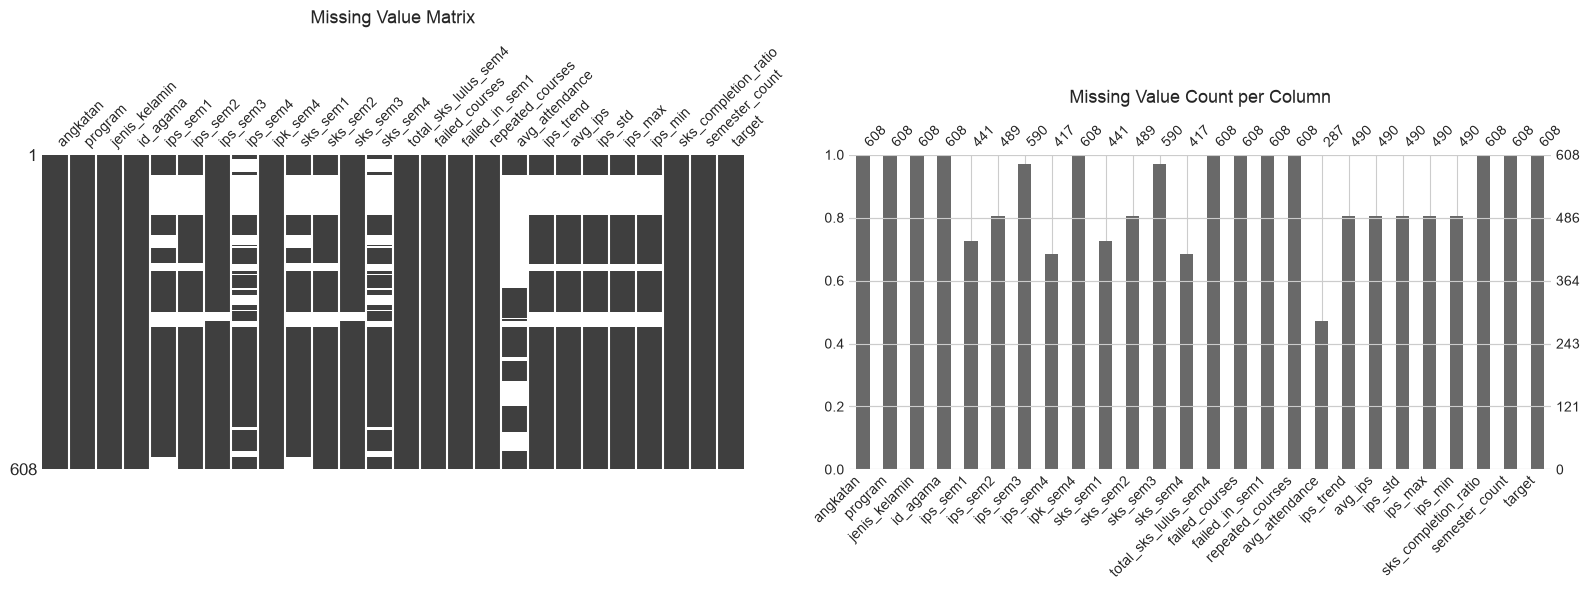

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

msno.matrix(df_eda, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Missing Value Matrix', fontsize=13, pad=15)

msno.bar(df_eda, ax=axes[1], fontsize=10)
axes[1].set_title('Missing Value Count per Column', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

In [8]:
# Missing by angkatan (is it concentrated in old cohorts?)
missing_by_angkatan = df_eda.groupby('angkatan').apply(
    lambda g: g[ips_cols].isnull().sum(axis=1).mean()
)
print('Rata-rata missing IPS per mahasiswa, by angkatan:')
missing_by_angkatan

Rata-rata missing IPS per mahasiswa, by angkatan:


angkatan
2015   1.9914
2016   0.8889
2017   0.8750
2018   1.8478
2019   0.8519
2020   0.6250
2021   0.5000
2022   0.0276
2023   0.2600
dtype: float64

In [9]:
# Missing by semester_count (how many semesters the student has)
missing_by_sem = df_eda.groupby('semester_count').apply(
    lambda g: g[ips_cols].isnull().sum(axis=1).mean()
)
print('Rata-rata missing IPS per mahasiswa, by semester_count:')
missing_by_sem

Rata-rata missing IPS per mahasiswa, by semester_count:


semester_count
3    2.1675
4    0.1186
5    0.0000
6    0.0000
7    1.5278
8    1.4545
9    0.0000
12   3.0000
dtype: float64

## 3. Target Variable

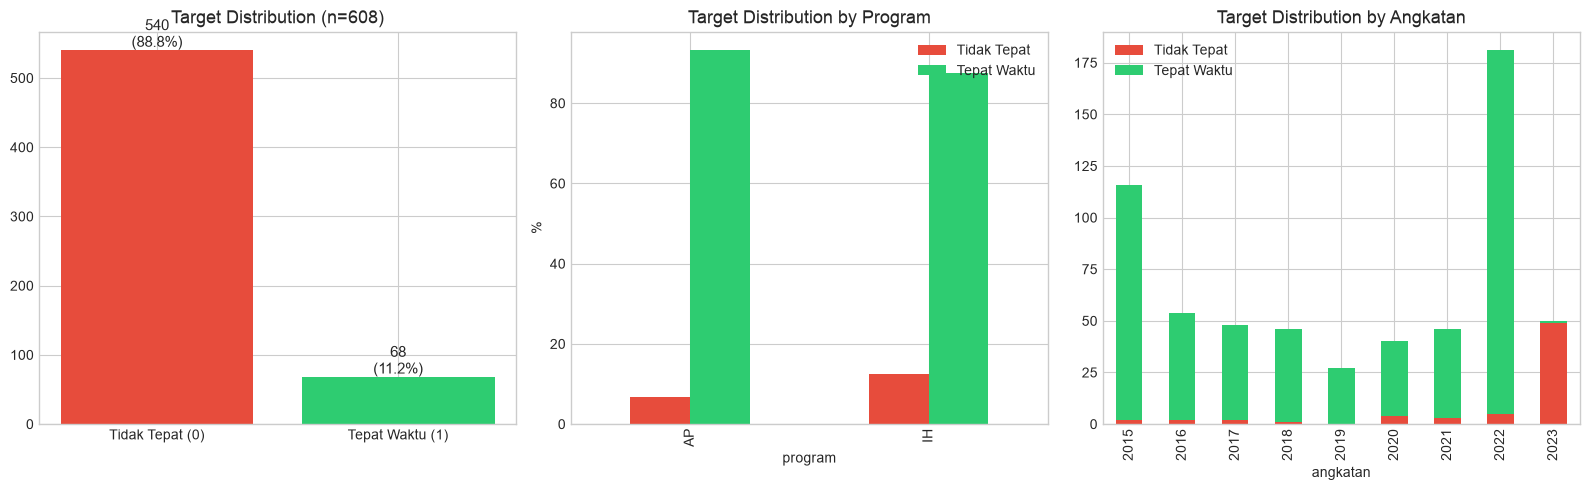

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

target_counts = df['target'].value_counts()
axes[0].bar(['Tidak Tepat (0)', 'Tepat Waktu (1)'], target_counts.values, color=['#E74C3C', '#2ECC71'])
axes[0].set_title(f'Target Distribution (n={len(df)})', fontsize=13)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

ct = pd.crosstab(df['program'], df['target'], margins=True)
ct_pct = pd.crosstab(df['program'], df['target'], normalize='index') * 100
ct_pct.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#2ECC71'])
axes[1].set_title('Target Distribution by Program', fontsize=13)
axes[1].set_ylabel('%')
axes[1].legend(['Tidak Tepat', 'Tepat Waktu'])

ct_angkatan = pd.crosstab(df['angkatan'], df['target'])
ct_angkatan.plot(kind='bar', stacked=True, ax=axes[2], color=['#E74C3C', '#2ECC71'])
axes[2].set_title('Target Distribution by Angkatan', fontsize=13)
axes[2].legend(['Tidak Tepat', 'Tepat Waktu'])

plt.tight_layout()
plt.show()

In [11]:
print('Crosstab: program x target')
print(ct)
print('\nPercentages by program:')
print(ct_pct.round(1))

Crosstab: program x target
target    0    1  All
program              
AP       10  137  147
IH       58  403  461
All      68  540  608

Percentages by program:
target        0       1
program                
AP       6.8000 93.2000
IH      12.6000 87.4000


## 4. Categorical Features vs Target

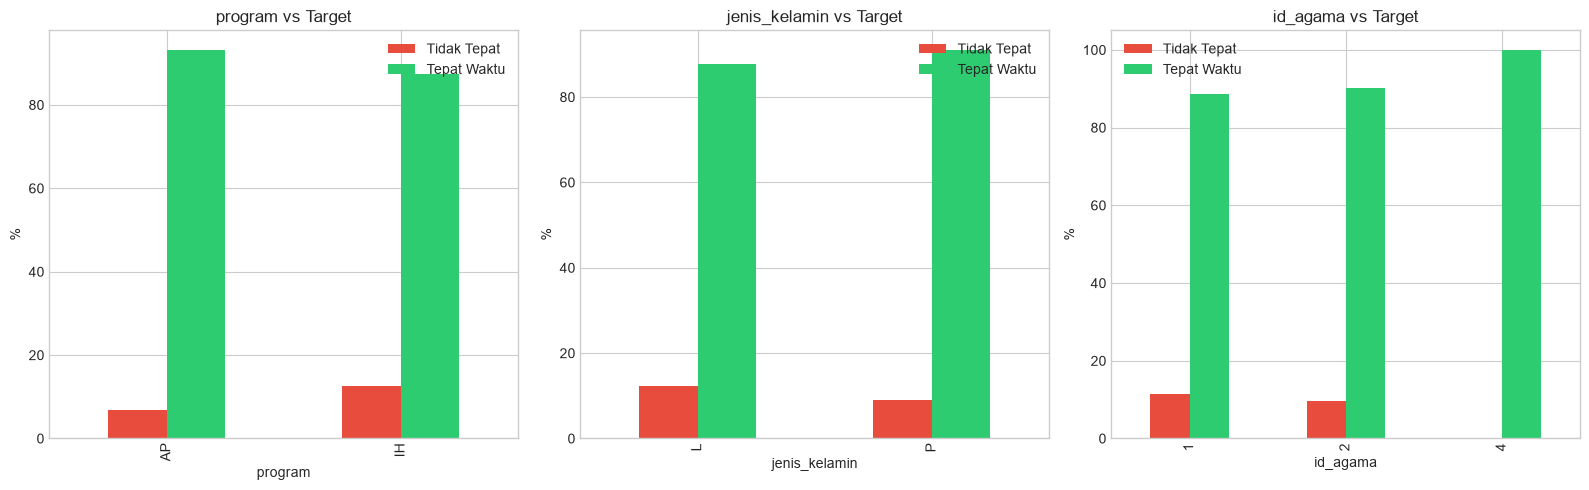

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['program', 'jenis_kelamin', 'id_agama']):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#E74C3C', '#2ECC71'])
    ax.set_title(f'{col} vs Target', fontsize=12)
    ax.set_ylabel('%')
    ax.set_xlabel(col)
    ax.legend(['Tidak Tepat', 'Tepat Waktu'])

plt.tight_layout()
plt.show()

## 5. IPS Features Distribution

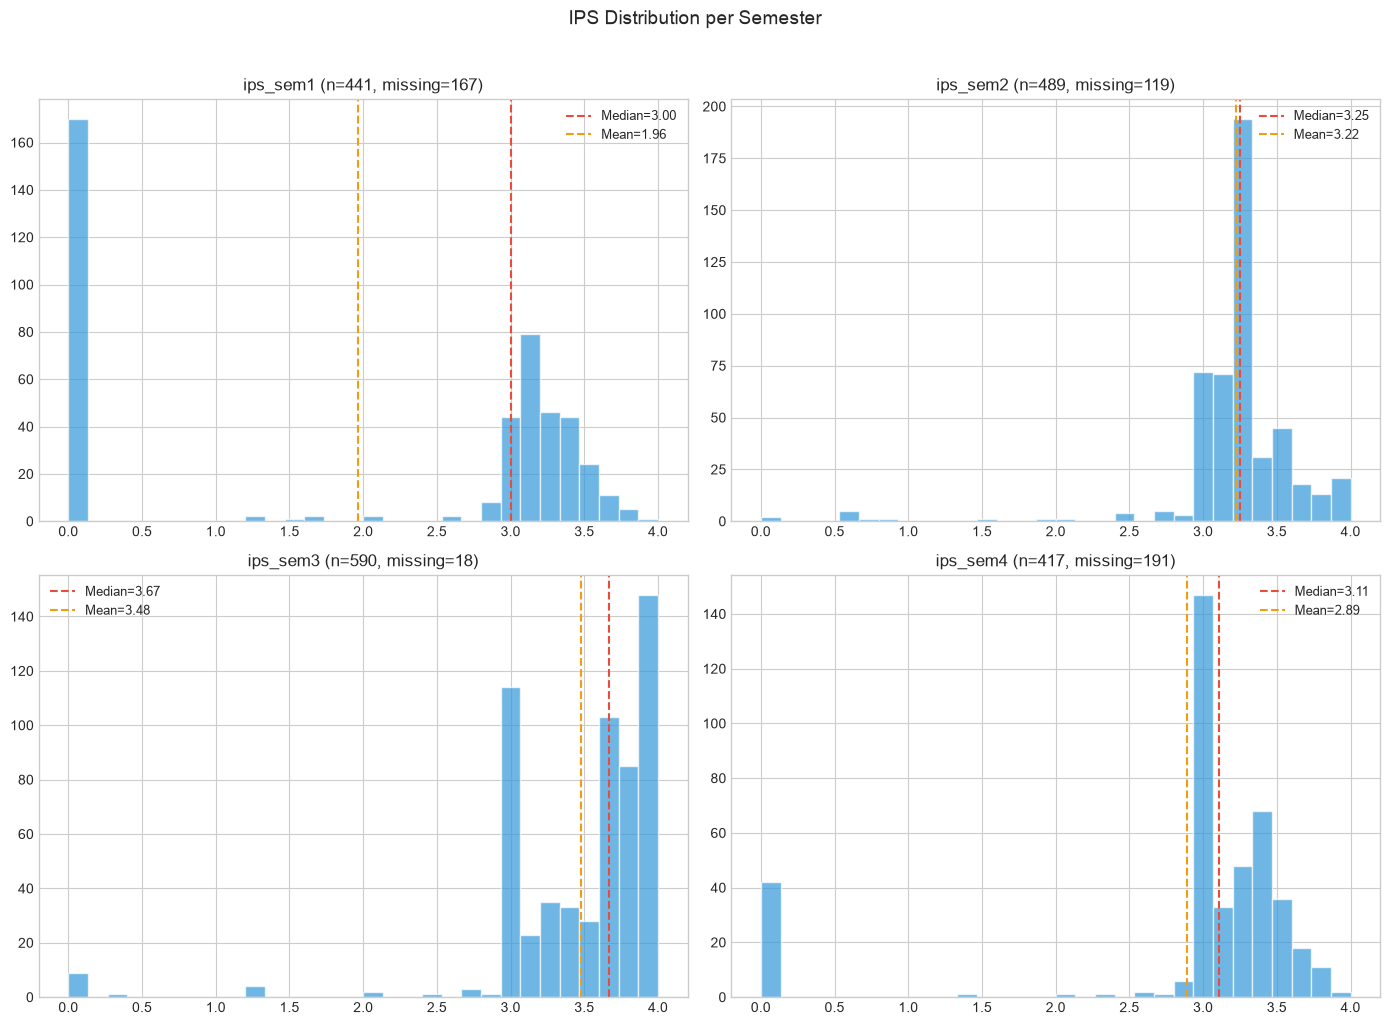

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ips_cols):
    # All values
    data = df[col].dropna()
    axes[i].hist(data, bins=30, alpha=0.7, color='#3498DB', edgecolor='white')
    axes[i].axvline(data.median(), color='#E74C3C', linestyle='--', label=f'Median={data.median():.2f}')
    axes[i].axvline(data.mean(), color='#F39C12', linestyle='--', label=f'Mean={data.mean():.2f}')
    axes[i].set_title(f'{col} (n={len(data)}, missing={df[col].isnull().sum()})', fontsize=12)
    axes[i].legend(fontsize=9)

plt.suptitle('IPS Distribution per Semester', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

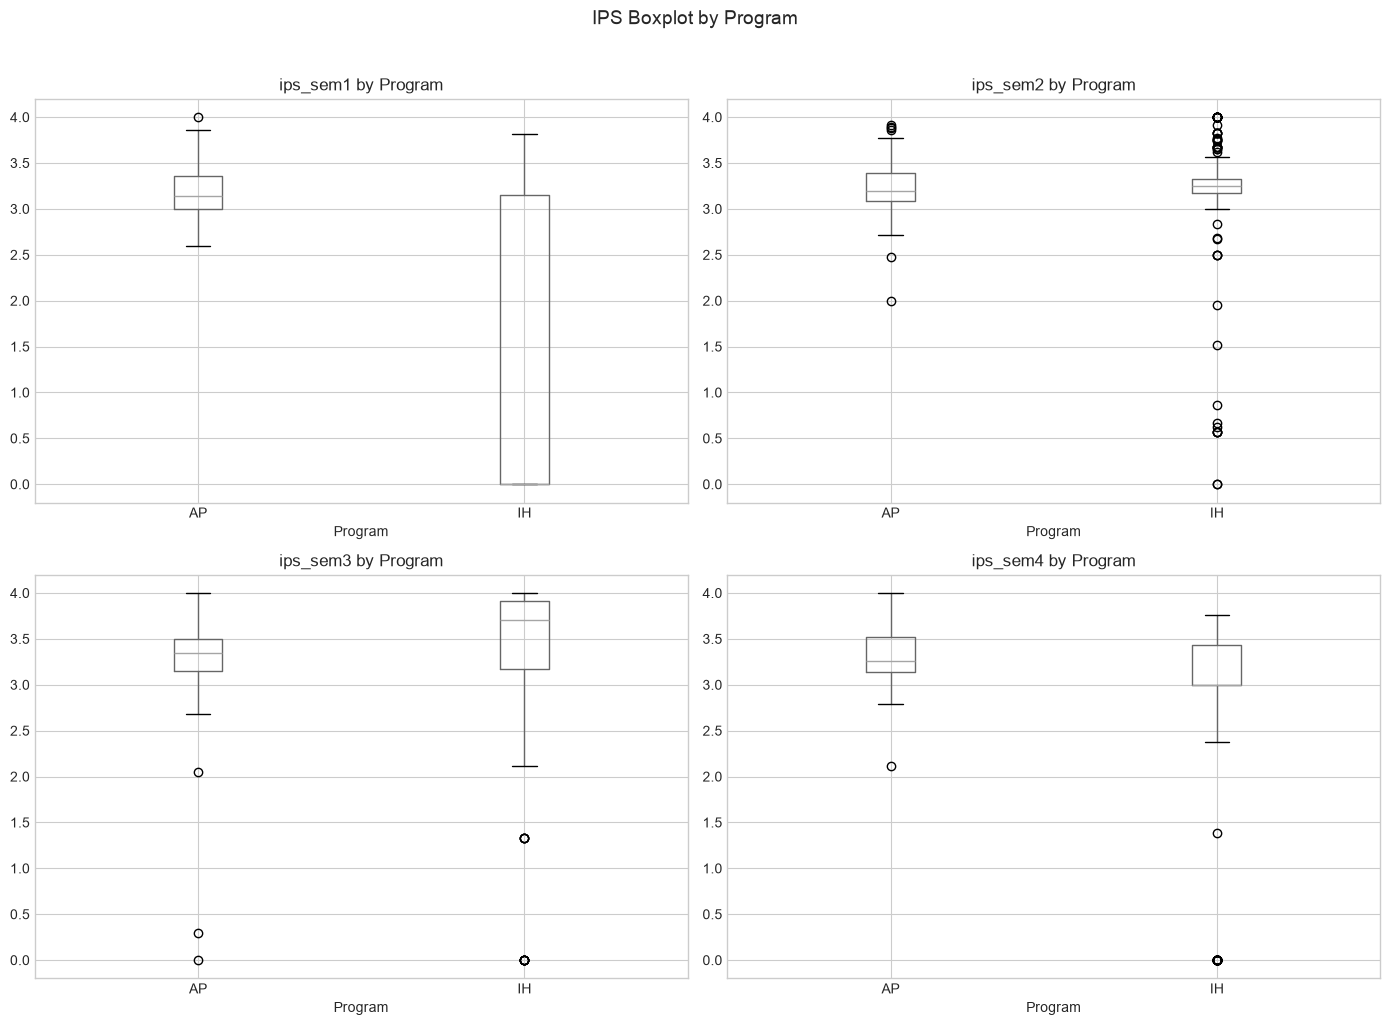

In [14]:
# IPS by program (boxplot)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ips_cols):
    df.boxplot(column=col, by='program', ax=axes[i])
    axes[i].set_title(f'{col} by Program', fontsize=12)
    axes[i].set_xlabel('Program')

plt.suptitle('IPS Boxplot by Program', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

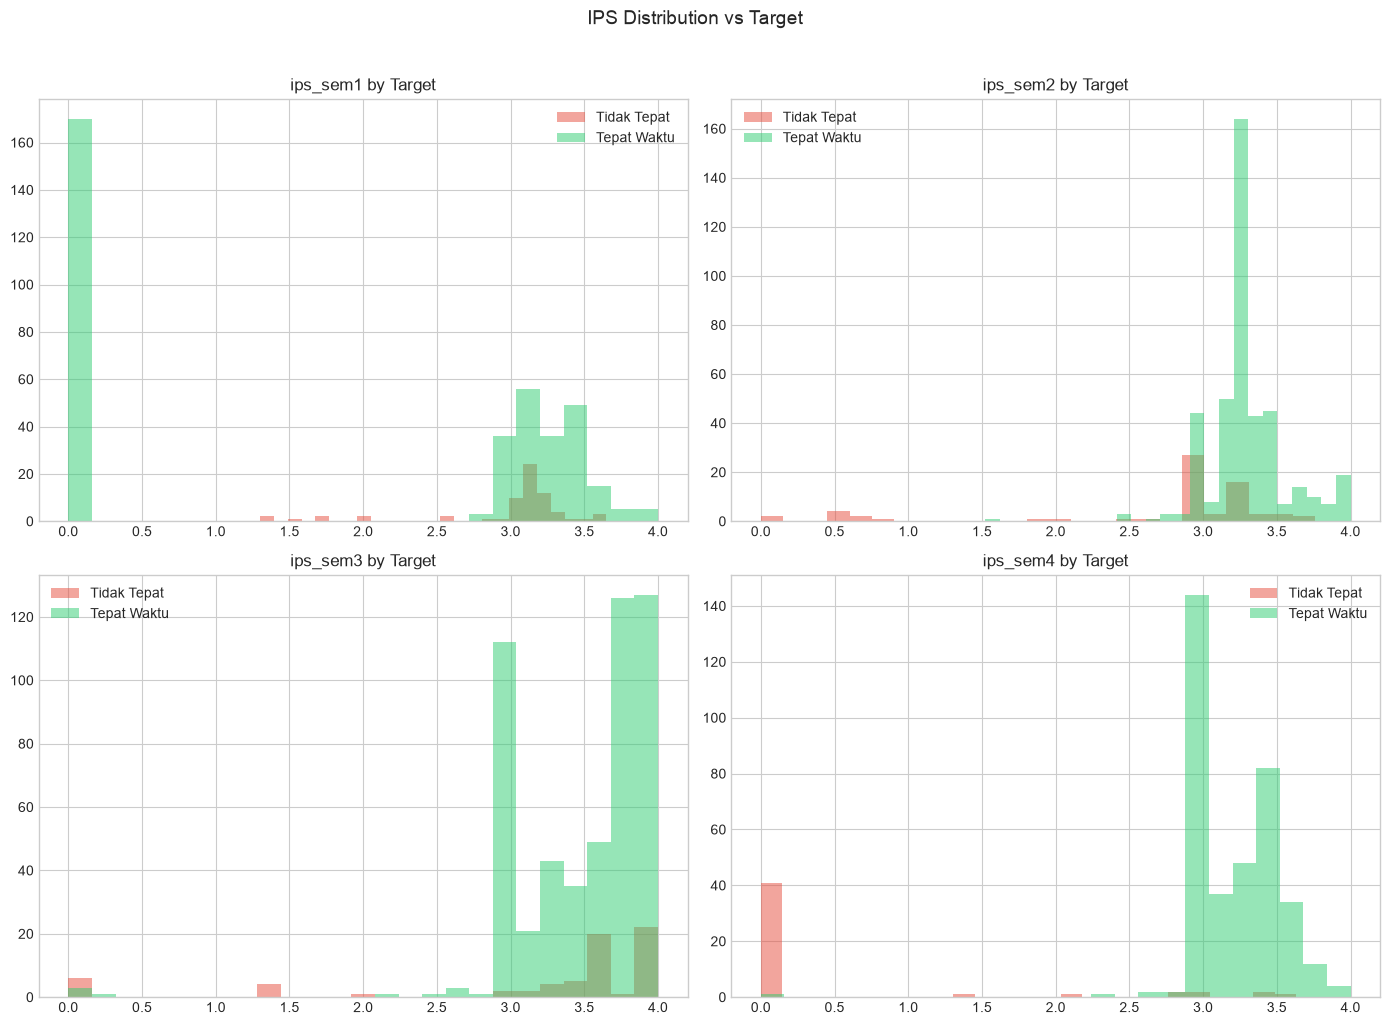

In [15]:
# IPS vs Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ips_cols):
    for target_val, color, label in [(0, '#E74C3C', 'Tidak Tepat'), (1, '#2ECC71', 'Tepat Waktu')]:
        data = df[df['target'] == target_val][col].dropna()
        axes[i].hist(data, bins=25, alpha=0.5, color=color, label=label)
    axes[i].set_title(f'{col} by Target', fontsize=12)
    axes[i].legend()

plt.suptitle('IPS Distribution vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. SKS Features

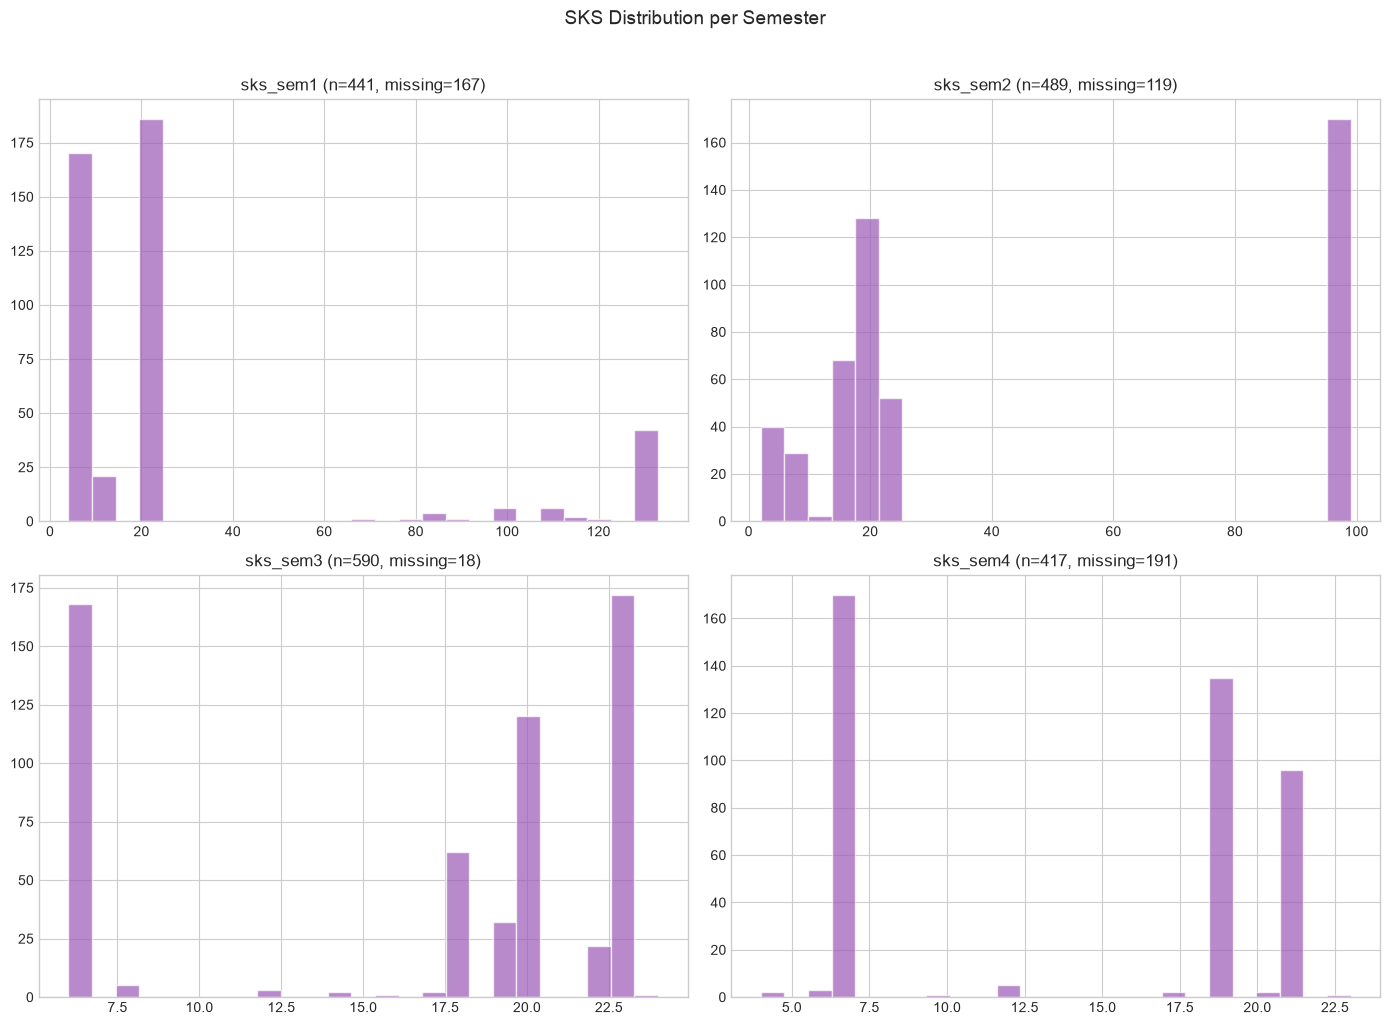

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(sks_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=25, alpha=0.7, color='#9B59B6', edgecolor='white')
    axes[i].set_title(f'{col} (n={len(data)}, missing={df[col].isnull().sum()})', fontsize=12)

plt.suptitle('SKS Distribution per Semester', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Grade Features

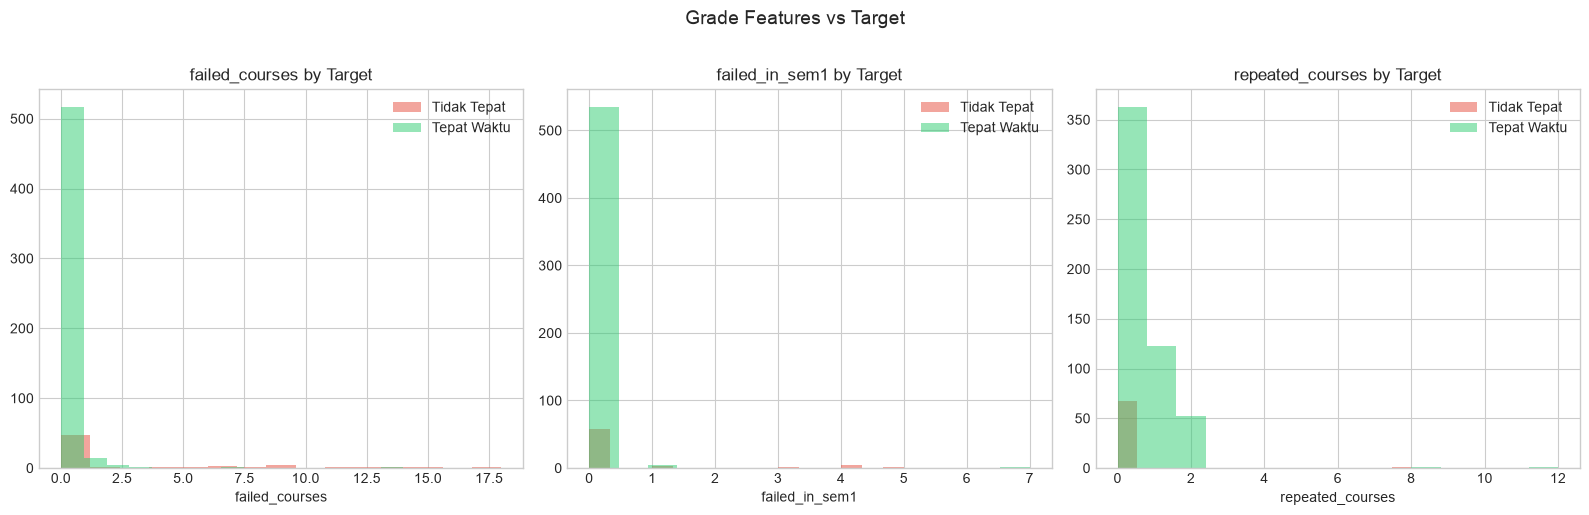

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, grade_cols):
    for target_val, color, label in [(0, '#E74C3C', 'Tidak Tepat'), (1, '#2ECC71', 'Tepat Waktu')]:
        data = df[df['target'] == target_val][col]
        ax.hist(data, bins=15, alpha=0.5, color=color, label=label)
    ax.set_title(f'{col} by Target', fontsize=12)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Grade Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Summary stats for grade features by target
df.groupby('target')[grade_cols].describe().round(2)

failed_courses                                                    \
                count   mean    std    min    25%    50%    75%     max   
target                                                                    
0             68.0000 3.0000 5.0500 0.0000 0.0000 0.0000 5.2500 18.0000   
1            540.0000 0.0900 0.7300 0.0000 0.0000 0.0000 0.0000 14.0000   

       failed_in_sem1                                                   \
                count   mean    std    min    25%    50%    75%    max   
target                                                                   
0             68.0000 0.4400 1.2000 0.0000 0.0000 0.0000 0.0000 5.0000   
1            540.0000 0.0200 0.3100 0.0000 0.0000 0.0000 0.0000 7.0000   

       repeated_courses                                                    
                  count   mean    std    min    25%    50%    75%     max  
target                                                                     
0               68.0000 0.1200 0.9700 0.0000 0.0000 0.0000 0.0000  8.0000  
1              540.0000 0.4600 0.8900 0.0000 0.0000 0.0000 1.0000 12.0000

## 8. Derived Features

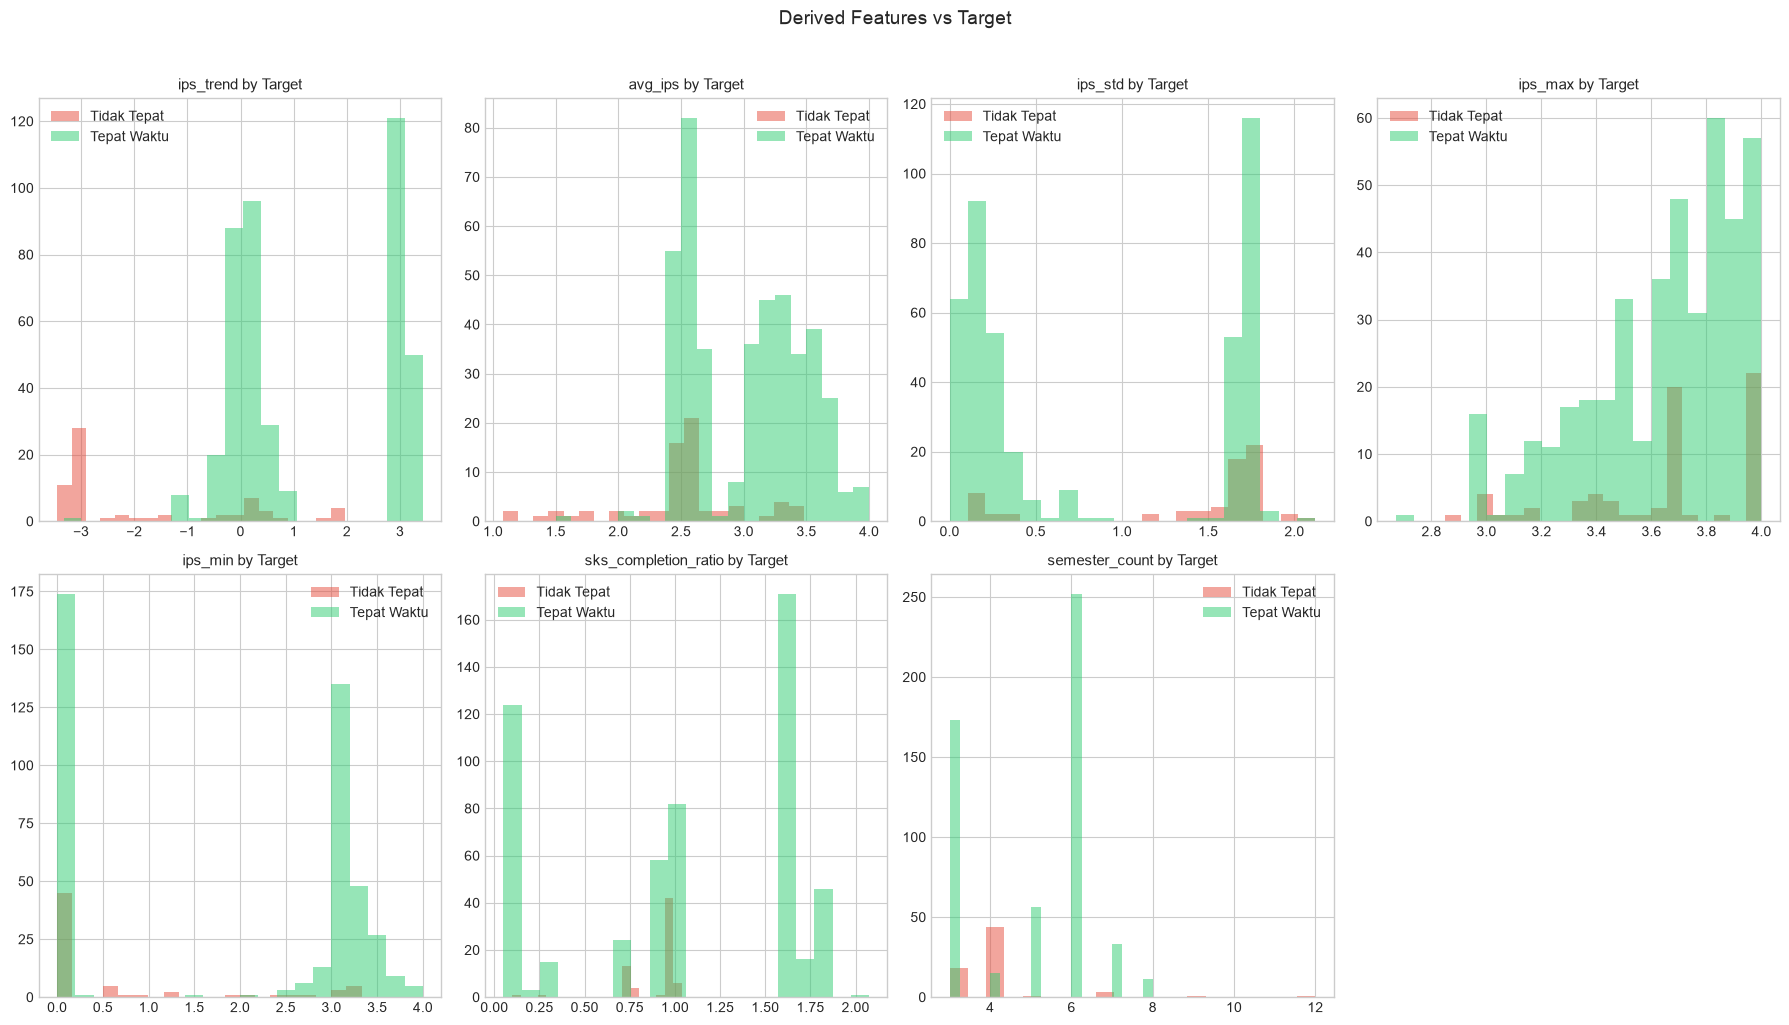

In [19]:
derived_subset = [c for c in derived_cols if c != 'avg_attendance']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(derived_subset):
    for target_val, color, label in [(0, '#E74C3C', 'Tidak Tepat'), (1, '#2ECC71', 'Tepat Waktu')]:
        data = df[df['target'] == target_val][col].dropna()
        axes[i].hist(data, bins=20, alpha=0.5, color=color, label=label)
    axes[i].set_title(f'{col} by Target', fontsize=11)
    axes[i].legend()

# Hide unused subplots
for j in range(len(derived_subset), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Derived Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Summary stats for derived features by target
df.groupby('target')[derived_subset].describe().round(3)

ips_trend                                                        \
           count    mean    std     min     25%     50%     75%    max   
target                                                                   
0        67.0000 -1.8570 1.7310 -3.4500 -3.1000 -3.0000 -0.1100 1.9700   
1       423.0000  1.3000 1.5440 -3.3300  0.0100  0.3800  3.0000 3.4300   

        avg_ips                                                   ips_std  \
          count   mean    std    min    25%    50%    75%    max    count   
target                                                                      
0       67.0000 2.4840 0.4940 1.0820 2.4180 2.5250 2.5650 3.4830  67.0000   
1      423.0000 3.0120 0.4590 1.5000 2.5280 3.0620 3.3980 4.0000 423.0000   

                                                         ips_max         \
         mean    std    min    25%    50%    75%    max    count   mean   
target                                                                    
0      1.4030 0.5900 0.1050 1.3980 1.6630 1.7480 2.1210  67.0000 3.6520   
1      0.8330 0.7570 0.0000 0.1590 0.3210 1.7110 2.1210 423.0000 3.6520   

                                                  ips_min                \
          std    min    25%    50%    75%    max    count   mean    std   
target                                                                    
0      0.3230 2.8500 3.4550 3.6700 4.0000 4.0000  67.0000 0.6590 1.1390   
1      0.2780 2.6700 3.4700 3.7000 3.8600 4.0000 423.0000 1.8520 1.5710   

                                          sks_completion_ratio                \
          min    25%    50%    75%    max                count   mean    std   
target                                                                         
0      0.0000 0.0000 0.0000 0.6450 3.3300              68.0000 0.8990 0.1620   
1      0.0000 0.0000 3.0000 3.1400 4.0000             540.0000 1.0460 0.6540   

                                          semester_count                       \
          min    25%    50%    75%    max          count   mean    std    min   
target                                                                          
0      0.1000 0.7880 0.9750 0.9750 1.0380        68.0000 4.0740 1.4180 3.0000   
1      0.0500 0.2620 1.0250 1.6620 2.0750       540.0000 4.9810 1.4860 3.0000   

                                     
          25%    50%    75%     max  
target                               
0      3.0000 4.0000 4.0000 12.0000  
1      3.0000 6.0000 6.0000  8.0000

## 9. Attendance Analysis

avg_attendance: 287 non-null, 321 missing (52.8%)
Stats: mean=82.35, median=89.80, std=19.31


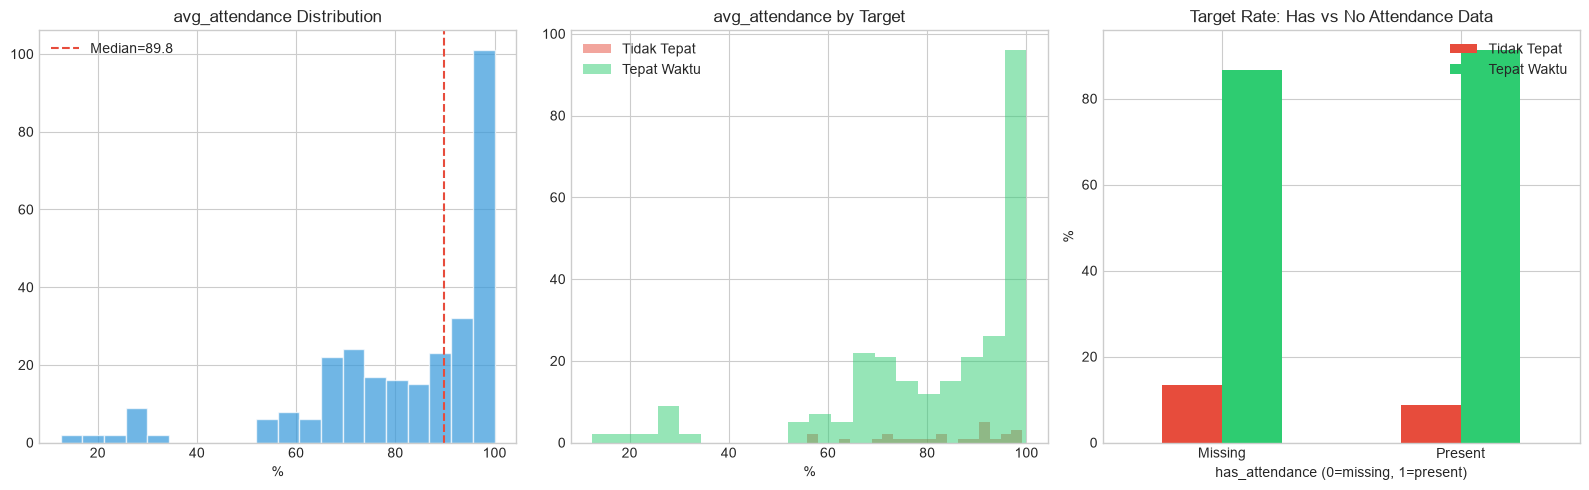


Target rate by has_attendance:
target               0       1
has_attendance                
0              13.4000 86.6000
1               8.7000 91.3000


In [21]:
att_data = df['avg_attendance'].dropna()
print(f'avg_attendance: {len(att_data)} non-null, {df["avg_attendance"].isnull().sum()} missing ({df["avg_attendance"].isnull().mean()*100:.1f}%)')
print(f'Stats: mean={att_data.mean():.2f}, median={att_data.median():.2f}, std={att_data.std():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
axes[0].hist(att_data, bins=20, alpha=0.7, color='#3498DB', edgecolor='white')
axes[0].axvline(att_data.median(), color='#E74C3C', linestyle='--', label=f'Median={att_data.median():.1f}')
axes[0].set_title('avg_attendance Distribution', fontsize=12)
axes[0].set_xlabel('%')
axes[0].legend()

# By target
for target_val, color, label in [(0, '#E74C3C', 'Tidak Tepat'), (1, '#2ECC71', 'Tepat Waktu')]:
    data = df[df['target'] == target_val]['avg_attendance'].dropna()
    axes[1].hist(data, bins=20, alpha=0.5, color=color, label=label)
axes[1].set_title('avg_attendance by Target', fontsize=12)
axes[1].set_xlabel('%')
axes[1].legend()

# Missing target rate by has_attendance
df['has_attendance'] = df['avg_attendance'].notna().astype(int)
ct_att = pd.crosstab(df['has_attendance'], df['target'], normalize='index') * 100
ct_att.plot(kind='bar', ax=axes[2], color=['#E74C3C', '#2ECC71'])
axes[2].set_title('Target Rate: Has vs No Attendance Data', fontsize=12)
axes[2].set_xlabel('has_attendance (0=missing, 1=present)')
axes[2].set_ylabel('%')
axes[2].legend(['Tidak Tepat', 'Tepat Waktu'])
axes[2].set_xticklabels(['Missing', 'Present'], rotation=0)

plt.tight_layout()
plt.show()

print('\nTarget rate by has_attendance:')
print(ct_att.round(1))

## 10. Correlation Analysis

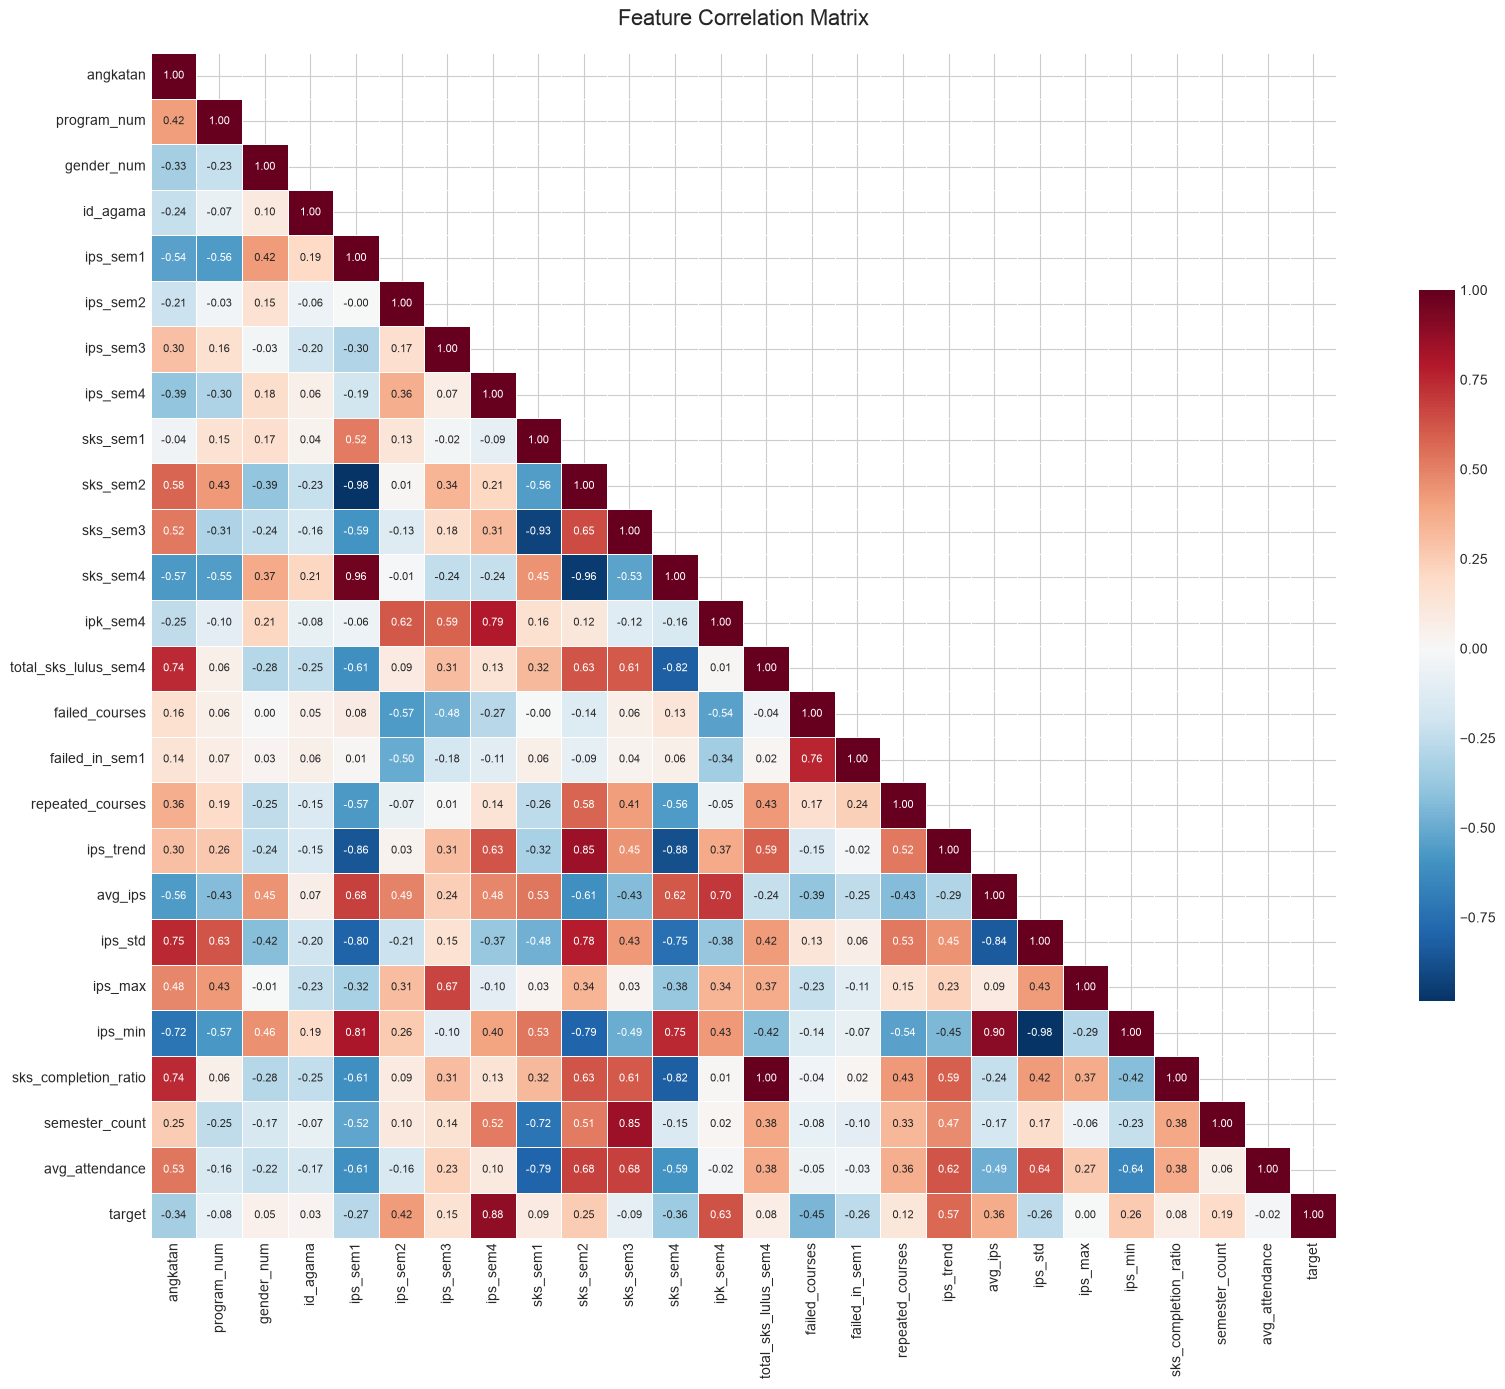

In [22]:
# Encode categoricals for correlation matrix
df_corr = df.copy()
df_corr['program_num'] = df_corr['program'].map({'AP': 0, 'IH': 1})
df_corr['gender_num'] = df_corr['jenis_kelamin'].map({'L': 0, 'P': 1})

corr_cols = (
    ['angkatan', 'program_num', 'gender_num', 'id_agama'] +
    ips_cols + sks_cols + ['ipk_sem4', 'total_sks_lulus_sem4'] +
    grade_cols + derived_cols + ['target']
)

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.6},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Top correlations with target:
ips_sem4                0.8772
ipk_sem4                0.6333
ips_trend               0.5691
ips_sem2                0.4206
avg_ips                 0.3648
ips_min                 0.2609
sks_sem2                0.2536
semester_count          0.1903
ips_sem3                0.1542
repeated_courses        0.1186
sks_sem1                0.0874
sks_completion_ratio    0.0752
total_sks_lulus_sem4    0.0752
gender_num              0.0497
id_agama                0.0314
ips_max                 0.0001
avg_attendance         -0.0162
program_num            -0.0785
sks_sem3               -0.0894
ips_std                -0.2573
failed_in_sem1         -0.2583
ips_sem1               -0.2720
angkatan               -0.3386
sks_sem4               -0.3563
failed_courses         -0.4515
Name: target, dtype: float64


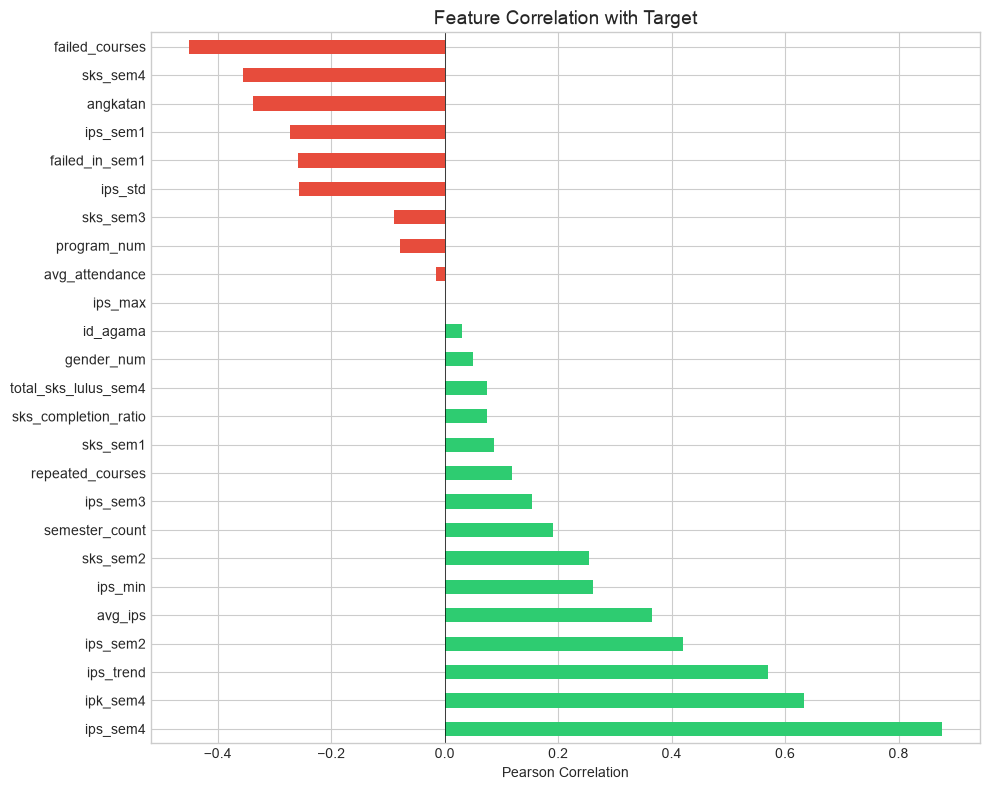

In [23]:
# Top correlations with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print('Top correlations with target:')
print(target_corr)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with Target', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

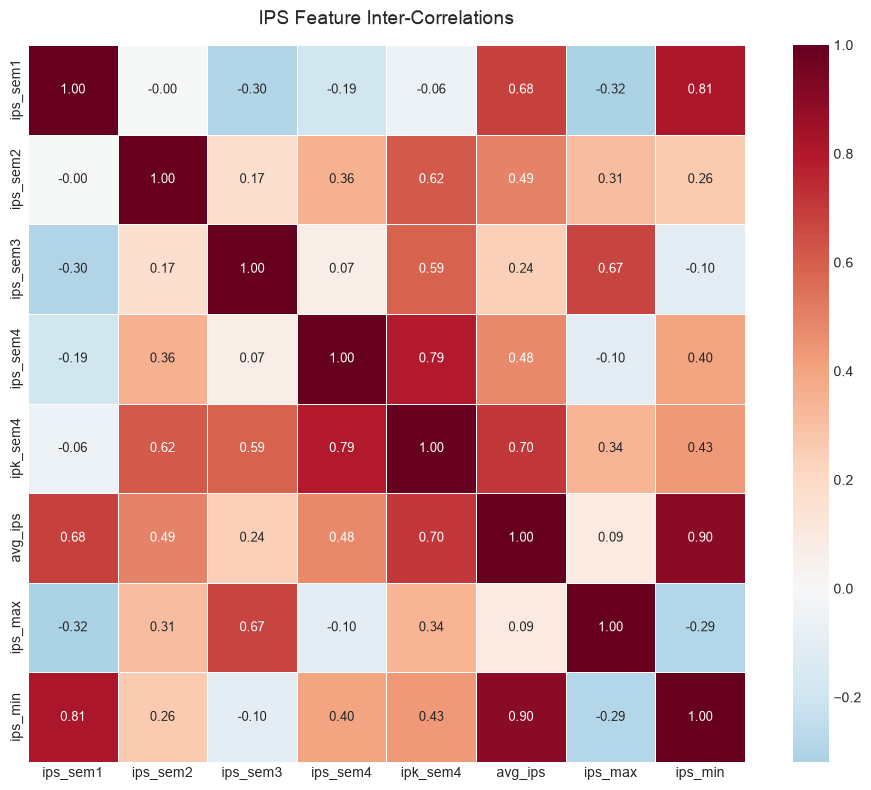

In [24]:
# IPS inter-correlations
fig, ax = plt.subplots(figsize=(10, 8))
ips_corr = df_corr[ips_cols + ['ipk_sem4', 'avg_ips', 'ips_max', 'ips_min']].corr()
sns.heatmap(ips_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('IPS Feature Inter-Correlations', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 11. Semester Count & Target Timing

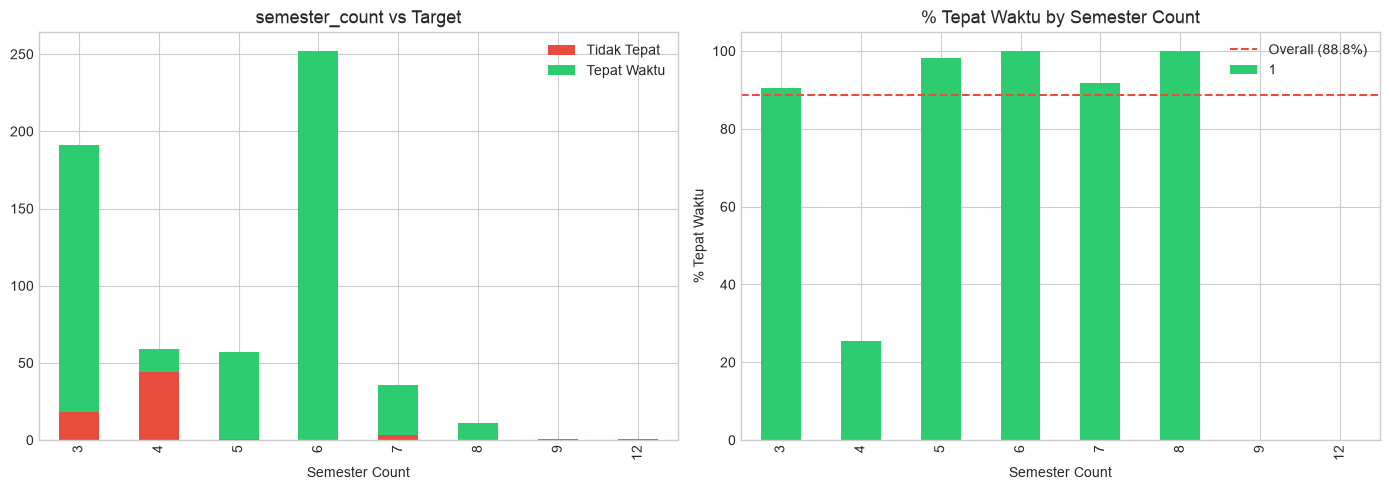

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sem_ct = pd.crosstab(df['semester_count'], df['target'])
sem_ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#E74C3C', '#2ECC71'])
axes[0].set_title('semester_count vs Target', fontsize=13)
axes[0].set_xlabel('Semester Count')
axes[0].legend(['Tidak Tepat', 'Tepat Waktu'])

sem_pct = pd.crosstab(df['semester_count'], df['target'], normalize='index') * 100
sem_pct[1].plot(kind='bar', ax=axes[1], color='#2ECC71')
axes[1].set_title('% Tepat Waktu by Semester Count', fontsize=13)
axes[1].set_ylabel('% Tepat Waktu')
axes[1].set_xlabel('Semester Count')
axes[1].axhline(88.8, color='#E74C3C', linestyle='--', label='Overall (88.8%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Outlier Check (IPS)

Students with at least one IPS = 0.0: 219
  Tepat waktu: 174
  Tidak tepat: 45
Students with at least one IPS = 4.0: 118


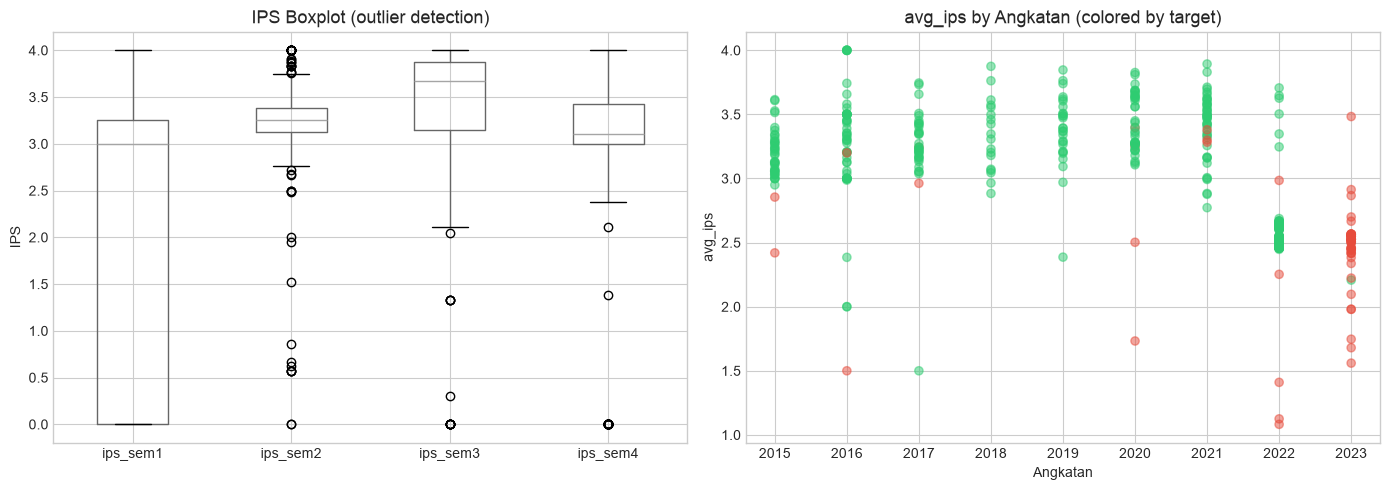

In [26]:
# Check for extreme IPS values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[ips_cols].boxplot(ax=axes[0])
axes[0].set_title('IPS Boxplot (outlier detection)', fontsize=13)
axes[0].set_ylabel('IPS')

# IPS = 0.0 cases
zero_ips = df[(df[ips_cols] == 0.0).any(axis=1)]
print(f'Students with at least one IPS = 0.0: {len(zero_ips)}')
print(f'  Tepat waktu: {(zero_ips["target"]==1).sum()}')
print(f'  Tidak tepat: {(zero_ips["target"]==0).sum()}')

# IPS = 4.0 cases
perfect_ips = df[(df[ips_cols] == 4.0).any(axis=1)]
print(f'Students with at least one IPS = 4.0: {len(perfect_ips)}')

axes[1].scatter(df['angkatan'], df['avg_ips'], alpha=0.5, c=df['target'].map({0: '#E74C3C', 1: '#2ECC71'}))
axes[1].set_title('avg_ips by Angkatan (colored by target)', fontsize=13)
axes[1].set_xlabel('Angkatan')
axes[1].set_ylabel('avg_ips')

plt.tight_layout()
plt.show()

## 13. Pairplot (Key Features)

Visualisasi hubungan pairwise untuk fitur-fitur paling penting.

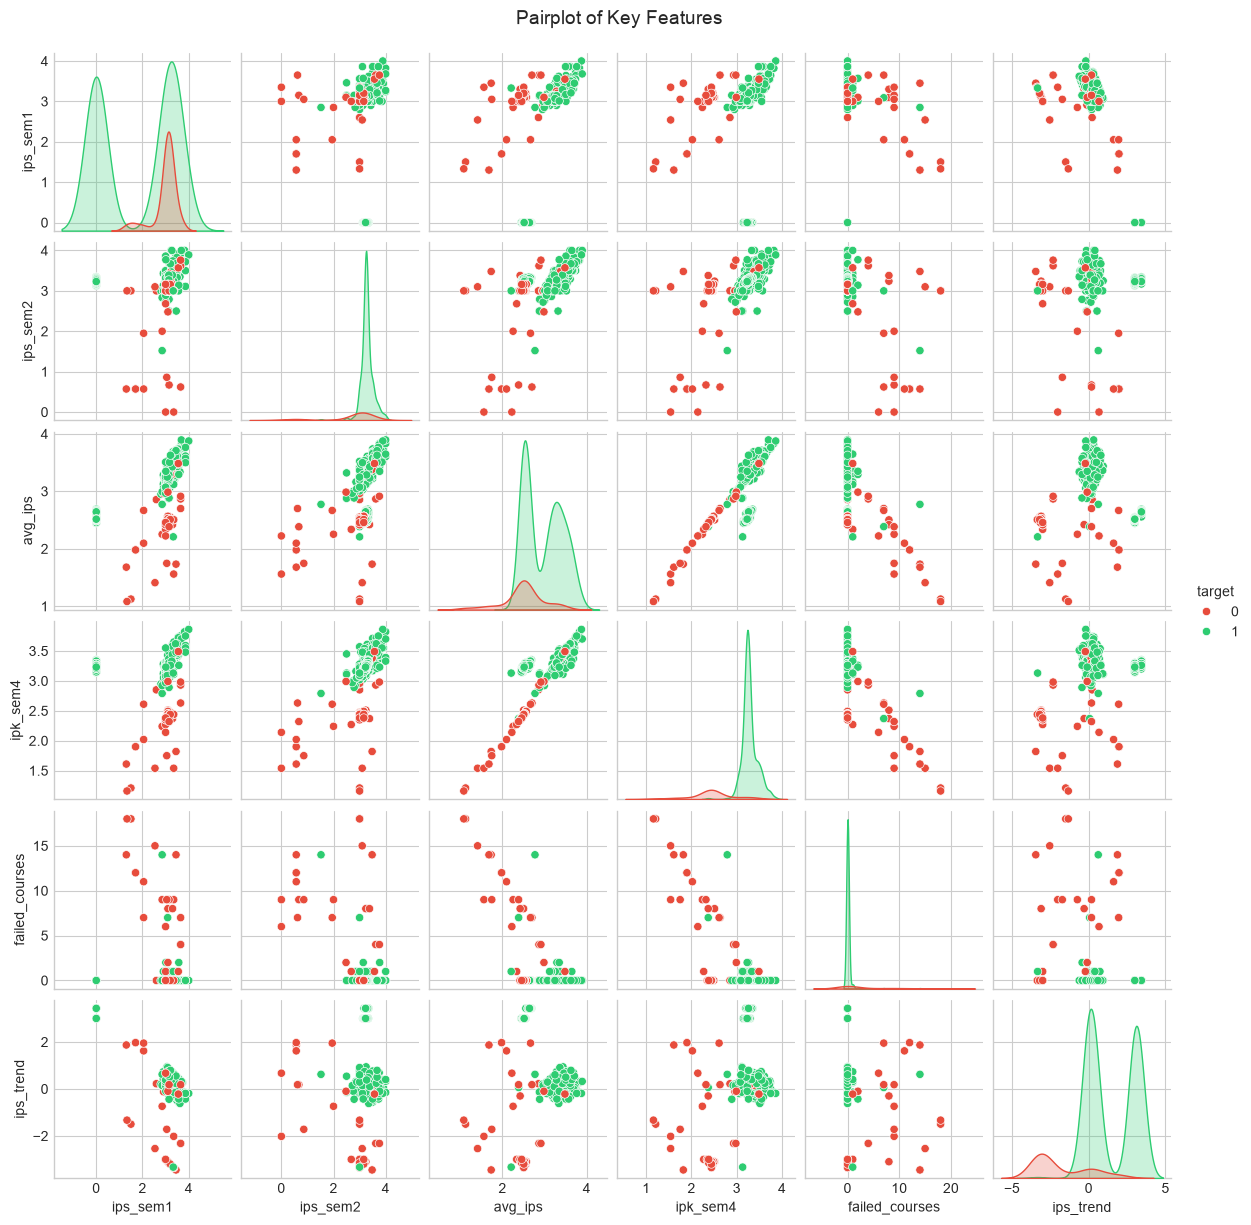

In [27]:
key_features = ['ips_sem1', 'ips_sem2', 'avg_ips', 'ipk_sem4', 
                'failed_courses', 'ips_trend', 'target']
df_pair = df_eda[key_features].dropna()
sns.pairplot(df_pair, hue='target', diag_kind='kde', 
             palette={0: '#E74C3C', 1: '#2ECC71'}, height=2)
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14)
plt.show()

---
## Summary & Interpretasi

Setelah menjalankan notebook ini, jawab pertanyaan berikut:

### A. Missing Values
1. Fitur mana yang missing >30%? Apakah pola missing-nya sistematik (by angkatan/semester)?
2. Apakah `avg_attendance` (52.8% missing) menunjukkan sinyal terhadap target? Kalau tidak → dropable.
3. Apakah ada baris yang missing di >5 kolom sekaligus? Perlu didrop?

### B. Distribusi
4. Apakah distribusi IPS per semester normal / skewed? Ada outlier ekstrem (0.0, 4.0)?
5. Bagaimana perbedaan distribusi IPS antara program AP vs IH?
6. Apakah ada fitur dengan near-zero variance?

### C. Target Separation
7. Fitur mana yang paling memisahkan kelas Tepat vs Tidak Tepat? (lihat histogram by target)
8. Apakah `failed_courses` dan `ips_sem1` jadi pemisah yang kuat?
9. Bagaimana `ips_trend` (improving vs declining) terkait target?

### D. Korelasi
10. Apa top 5 fitur paling berkorelasi dengan target?
11. Apakah ada multikolinearitas tinggi antar fitur IPS (r > 0.9)?
12. Fitur derived mana yang redundant dengan base features?

### E. Implikasi Preprocessing
13. Berdasarkan EDA, strategi imputasi apa yang paling masuk akal? Mean? Median? Per-group?
14. Fitur mana yang bisa didrop tanpa kehilangan sinyal?
15. Apakah perlu transformasi (log, sqrt) untuk fitur skewed?